<div style="background: white;
            padding: 30px 35px;
            border-radius: 8px;
            border-left: 6px solid #e94560;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;">

<h1 style="margin-bottom: 5px;">NB02: Risk Modelling — Value at Risk & Expected Shortfall</h1>

<p style="font-weight: bold; margin-top: 0;">Personal Project · Portfolio Risk Dashboard · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 12th April 2026</li>
    <li>🎯 <strong>Purpose:</strong> Quantify the downside risk of a 5-asset portfolio using three VaR methodologies and Expected Shortfall</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li><code>../data/raw/prices.csv</code> — cleaned daily adjusted closing prices from NB01</li>
    <li><code>../data/processed/returns.csv</code> — daily log returns from NB01</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/processed/portfolio_returns.csv</code> — weighted daily portfolio returns</li>
    <li><code>../figures/var_comparison.png</code> — VaR comparison across methods</li>
    <li><code>../figures/historical_var.png</code> — historical return distribution with VaR marked</li>
    <li><code>../figures/monte_carlo.png</code> — Monte Carlo simulation paths</li>
    <li><code>../figures/drawdown.png</code> — portfolio drawdown chart</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Portfolio return construction using weighted asset returns</li>
    <li>Historical VaR — empirical percentile method</li>
    <li>Parametric VaR — normal distribution assumption</li>
    <li>Monte Carlo VaR — simulated return paths</li>
    <li>Expected Shortfall (CVaR) — average loss beyond VaR</li>
    <li>Drawdown analysis — peak-to-trough loss visualisation</li>
</ul>

<p><strong>Workflow:</strong> Load Data → Build Portfolio → Historical VaR → Parametric VaR → Monte Carlo VaR → Expected Shortfall → Drawdown → Compare & Reflect</p>

</div>

## ⚙️ Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📂 Section 1: Load Data from NB01

### 📍 Load Prices & Returns

In [2]:
# Load the prices CSV saved in NB01 - the raw daily closing prices
# index_col="Date" sets the Date column as the row index rather than a regular column
# parse_dates=True converts the date strings into proper datetime objects for time series
prices  = pd.read_csv("../data/raw/prices.csv", index_col="Date", parse_dates=True)

# Load the log returns CSV saved in NB01 - already computed, no need to recalculate
returns = pd.read_csv("../data/processed/returns.csv", index_col="Date", parse_dates=True)

# Confirm both loaded correctly
print(f"✅ Data loaded")
print(f"📐 Prices shape  : {prices.shape}")
print(f"📐 Returns shape : {returns.shape}")
print(f"📅 Period        : {returns.index[0].date()} → {returns.index[-1].date()}")
returns.head()

✅ Data loaded
📐 Prices shape  : (2513, 5)
📐 Returns shape : (2512, 5)
📅 Period        : 2016-01-05 → 2025-12-30


,EEM,GLD,QQQ,SPY,TLT
Date,,,,,
2016-01-05,0.002233,0.002815,-0.001736,0.001690,-0.004043
2016-01-06,-0.019306,0.014337,-0.009652,-0.012694,0.013385
2016-01-07,-0.031351,0.014041,-0.031814,-0.024284,0.001793
2016-01-08,-0.010785,-0.004438,-0.008234,-0.011038,0.004469
2016-01-11,-0.000339,-0.008935,0.003071,0.000990,-0.011004


## 💼 Section 2: Build Portfolio Returns

### 📍 Construct Weighted Portfolio Returns

A portfolio return on any given day is simply the weighted average of each asset's return
that day. For example, if SPY is up 1% and makes up 35% of the portfolio, it contributes
0.35% to the overall portfolio return. We sum this across all five assets to get a single
daily return series for the whole portfolio.

In [4]:
# Define portfolio weights as a numpy array - same order as the columns in returns (SPY, TLT, GLD, QQQ, EEM)
# These must match the column order exactly otherwise the wrong weight gets applied to the wrong asset
WEIGHTS = np.array([0.35, 0.25, 0.15, 0.15, 0.10])  # SPY, TLT, GLD, QQQ, EEM

# Multiply each asset's daily return by its weight and sum across all 5 assets for every day
# returns is a (2512 x 5) table, WEIGHTS is a (5,) array
# .dot() multiplies and sums in one step - giving a single daily return number for the whole portfolio
portfolio_returns = returns.dot(WEIGHTS)

# Give the series a name for clarity when plotting or saving
portfolio_returns.name = "Portfolio"

# Print summary statistics
print(f"✅ Portfolio returns constructed")
print(f"📐 Shape         : {portfolio_returns.shape}")
print(f"📈 Mean daily return  : {portfolio_returns.mean():.4f} ({portfolio_returns.mean()*252:.2f} annualised)")
print(f"📉 Std daily return   : {portfolio_returns.std():.4f} ({portfolio_returns.std()*np.sqrt(252):.4f} annualised)")
print(f"⬇️  Worst single day  : {portfolio_returns.min():.4f} ({portfolio_returns.min()*100:.2f}%)")
print(f"⬆️  Best single day   : {portfolio_returns.max():.4f} ({portfolio_returns.max()*100:.2f}%)")

✅ Portfolio returns constructed
📐 Shape         : (2512,)
📈 Mean daily return  : 0.0004 (0.11 annualised)
📉 Std daily return   : 0.0084 (0.1328 annualised)
⬇️  Worst single day  : -0.0798 (-7.98%)
⬆️  Best single day   : 0.0651 (6.51%)


## 📐 Section 3: Historical VaR

### 📍 Step 1: Calculate Historical VaR

Historical VaR is the simplest and most intuitive method. We take the actual observed
return distribution and find the percentile that corresponds to our confidence level.
At 95% confidence, we are asking: "What loss did we exceed on only 5% of trading days?"
No assumptions about the shape of the distribution — we let the data speak for itself.
This is its biggest strength: it naturally captures fat tails and real crisis behaviour.
Its weakness is that it can only reflect risks that already occurred in the sample period.

In [5]:
# Define the three confidence levels we want to calculate VaR for
CONFIDENCE_LEVELS = [0.90, 0.95, 0.99]

# Create an empty dictionary to store the VaR result for each confidence level
historical_var = {}
for cl in CONFIDENCE_LEVELS:
    # Find the percentile of actual returns that corresponds to this confidence level
    # At 95% confidence: (1 - 0.95) * 100 = 5th percentile
    # The finds the return threshold below which only 5% of days fall
    var = np.percentile(portfolio_returns, (1 - cl) * 100)
    
    # Store the result
    historical_var[cl] = var
    
    # Print in plain English - 1/(1-cl) gives the frequency e.g. 1/0.05 = 20 days
    print(f"  Historical VaR ({int(cl*100)}%) : {var:.4f}  →  on 1 in {int(1/(1-cl))} days, "
          f"portfolio loses more than {abs(var)*100:.2f}%")

  Historical VaR (90%) : -0.0089  →  on 1 in 10 days, portfolio loses more than 0.89%
  Historical VaR (95%) : -0.0128  →  on 1 in 19 days, portfolio loses more than 1.28%
  Historical VaR (99%) : -0.0215  →  on 1 in 99 days, portfolio loses more than 2.15%


### 📍 Step 2: Visualise Historical VaR

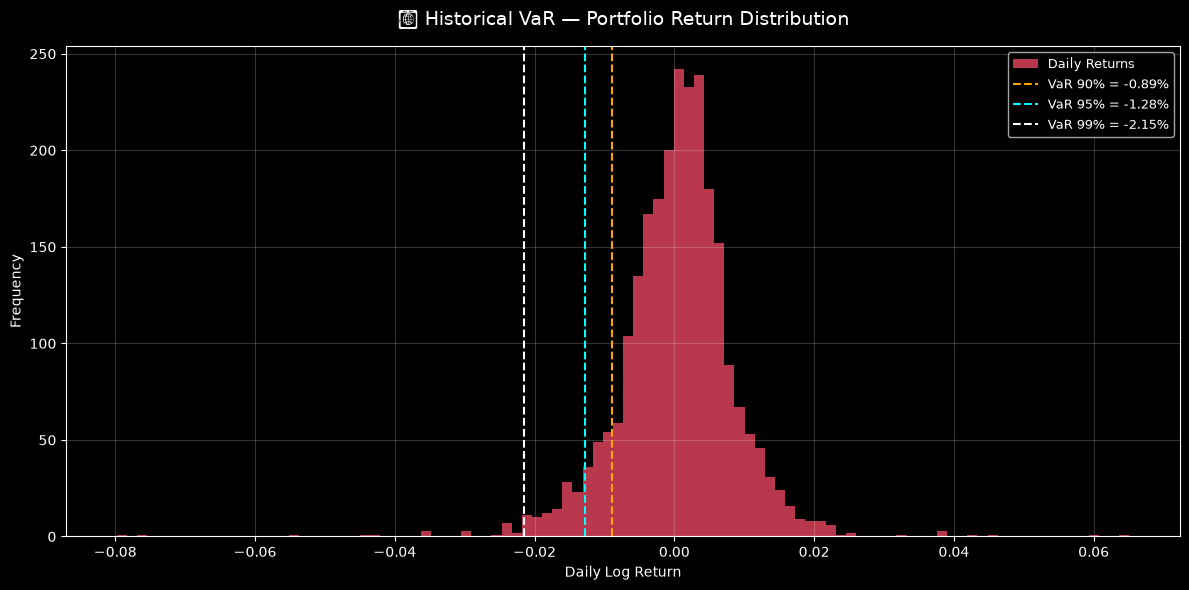

💾 Saved to ../figures/historical_var.png


In [6]:
# Create a single chart
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the histogram of all 2,512 daily portfolio returns
# bins=100 splits returns into 100 buckets for a detailed view of the distribution shape
ax.hist(portfolio_returns, bins=100, color="#e94560", edgecolor="none", alpha=0.8, label="Daily Returns")

# Assign a different colour to each VaR line so they're easy to distinguish
colors = ["orange", "cyan", "white"]

# Loop through each confidence level and draw a vertical dashed line at its VaR threshold
# zip() pairs each (confidence level, VaR value) with its corresponding colour
for (cl, var), color in zip(historical_var.items(), colors):
    ax.axvline(var, color=color, linestyle="--", linewidth=1.5,
               label=f"VaR {int(cl*100)}% = {var*100:.2f}%")

# Add labels, title, legend and grid
ax.set_title("📐 Historical VaR — Portfolio Return Distribution", fontsize=14, pad=15)
ax.set_xlabel("Daily Log Return")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/historical_var.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/historical_var.png")

## 📊 Section 4: Parametric VaR

### 📍 Calculate Parametric VaR

Parametric VaR assumes returns follow a normal distribution. We estimate the mean and
standard deviation of portfolio returns, then use the properties of the normal distribution
to calculate the loss at a given confidence level. The formula is:

**VaR = μ - z × σ**

Where μ is the mean daily return, σ is the standard deviation, and z is the z-score
corresponding to the confidence level (e.g. 1.645 for 95%, 2.326 for 99%).

The advantage is simplicity and speed — no need for large historical datasets. The major
weakness, which NB01's return distributions already flagged, is that real returns have
fat tails. The normal distribution underestimates the probability of extreme losses,
so parametric VaR will likely give a less conservative estimate than historical VaR.

In [7]:
# Calculate the mean (average daily return) and standard deviation (daily volatility)
# These two numbers are all parametric VaR needs - it assumes everything else follows a normal distribution
mu    = portfolio_returns.mean()
sigma = portfolio_returns.std()

# Z-scores tell us how many standard deviations below the mean each confidence level sits
# These are fixed mathematical constants from the normal distribution:
# 90% -> 1.282 standard deviations below mean
# 95% -> 1.645 standard deviations below mean
# 99% -> 2.326 standard deviations below mean
z_scores = {0.90: 1.282, 0.95: 1.645, 0.99: 2.326}

# Create empty dictionary to store results
parametric_var = {}

# Loop through each confidence level and apply the formula: VaR = μ - z × σ
for cl in CONFIDENCE_LEVELS:
    var = mu - z_scores[cl] * sigma # subtract z standard deviations below the mean
    parametric_var[cl] = var
    print(f"  Parametric VaR ({int(cl*100)}%) : {var:.4f}  →  {abs(var)*100:.2f}% loss threshold")

# Print the two inputs to the formula so they're visible and auditable
print(f"\n  μ (mean daily return) : {mu:.6f}")
print(f"  σ (daily volatility)  : {sigma:.6f}")

  Parametric VaR (90%) : -0.0103  →  1.03% loss threshold
  Parametric VaR (95%) : -0.0133  →  1.33% loss threshold
  Parametric VaR (99%) : -0.0190  →  1.90% loss threshold

  μ (mean daily return) : 0.000433
  σ (daily volatility)  : 0.008368


## 🎲 Section 5: Monte Carlo VaR

### 📍 Step 1: Run Monte Carlo Simulation

Monte Carlo VaR simulates thousands of possible future return paths by drawing random
returns from a normal distribution calibrated to our portfolio's historical mean and
standard deviation. We then look at the distribution of simulated outcomes to estimate VaR.

The intuition is: instead of relying only on what actually happened (historical VaR),
we generate a huge number of hypothetical scenarios and ask what the worst outcomes
look like across all of them. With 10,000 simulations we get a smooth, stable estimate
even in the tails. Like parametric VaR it assumes normality, but it is more flexible —
in more advanced versions you can simulate from non-normal distributions to better
capture fat tails.

In [8]:
# Set a random seed so results are identical every time the cell is run
# Without this, the random numbers would change on every run, giving slightly different VaR estimates
np.random.seed(42)

# Define how many hypothetical scenarios to simulate
N_SIMULATIONS = 10_000 # 10,000 random days

# We are calculating 1-day VaR - how much could the portfolio lose in a single day
N_DAYS        = 1  # 1-day VaR

# Generate 10,000 random daily returns drawn from a normal distribution
# calibrated to our portfolio's actual mean (mu) and volatility (sigma) from Section 4
# This creates 10,000 hypothetical "what if" days
simulated_returns = np.random.normal(mu, sigma, N_SIMULATIONS)

# Create empty dictionary to store results
monte_carlo_var = {}

# Loop through each confidence level and find the percentile of the simulated distribution
# This is identical in logic to historical VaR - but using simulated data instead of real data
for cl in CONFIDENCE_LEVELS:
    var = np.percentile(simulated_returns, (1 - cl) * 100)
    monte_carlo_var[cl] = var
    print(f"  Monte Carlo VaR ({int(cl*100)}%) : {var:.4f}  →  {abs(var)*100:.2f}% loss threshold")

  Monte Carlo VaR (90%) : -0.0104  →  1.04% loss threshold
  Monte Carlo VaR (95%) : -0.0134  →  1.34% loss threshold
  Monte Carlo VaR (99%) : -0.0190  →  1.90% loss threshold


### 📍 Step 2: Visualise Monte Carlo Simulation Paths

Here we simulate 50 possible 30-day portfolio return paths to visualise the range of
outcomes the portfolio could experience over the next month. Each line is one possible
future — the spread of lines shows the uncertainty in future returns.

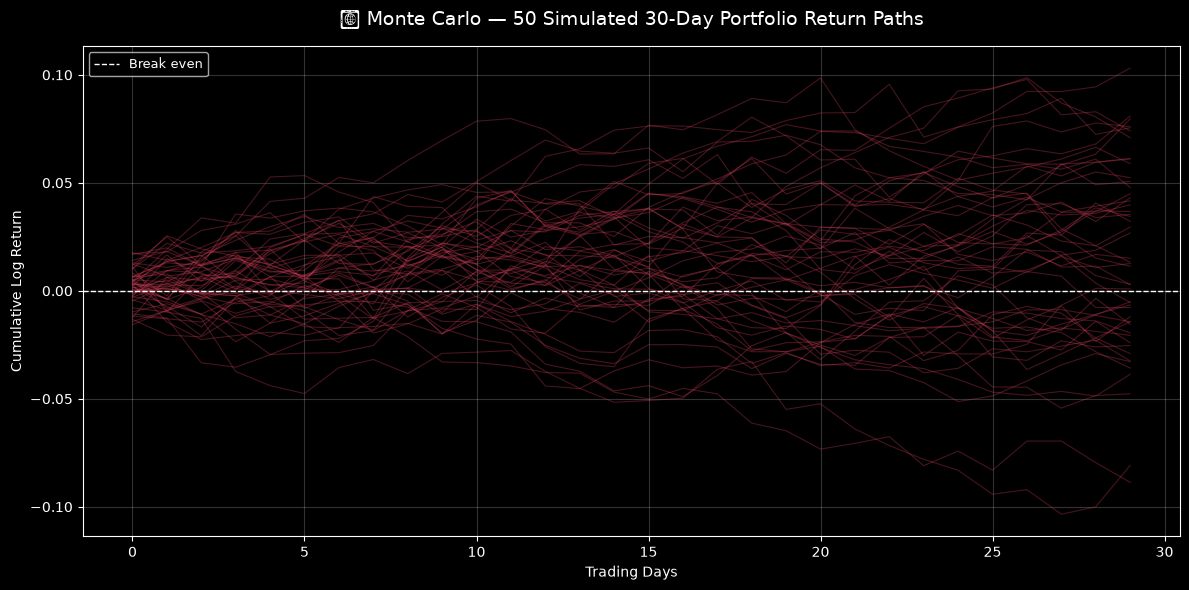

💾 Saved to ../figures/monte_carlo.png


In [10]:
# Number of simulation paths to draw on the chart
N_PATHS = 50

# Number of trading days to simulate forward - roughly one month
N_DAYS_PATH = 30

fig, ax = plt.subplots(figsize=(12, 6))

# Loop 50 times - each iteration creates one possible future path
for _ in range(N_PATHS):
    # Generate 30 random daily returns from the normal distribution
    # calibrated to our portfolio's actual mean and volatility

    # Cumulative sum converts daily returns into a running total
    # e.g. [+0.5%, -0.3%, +0.8%] becomes [+0.5%, +0.2%, +1.0%]
    # This shows where the portfolio ends up after each day
    path = np.cumsum(np.random.normal(mu, sigma, N_DAYS_PATH))

    # Plot this path — alpha=0.3 makes each line semi-transparent
    # so overlapping paths create a natural density effect
    ax.plot(path, color="#e94560", alpha=0.3, linewidth=0.8)

# Draw a horizontal line at zero — the break even point
# Paths above this line are in profit, paths below are in loss
ax.axhline(0, color="white", linestyle="--", linewidth=1, label="Break even")

ax.set_title("🎲 Monte Carlo — 50 Simulated 30-Day Portfolio Return Paths", fontsize=14, pad=15)
ax.set_xlabel("Trading Days")
ax.set_ylabel("Cumulative Log Return")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/monte_carlo.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/monte_carlo.png")

## ⚠️ Section 6: Expected Shortfall (CVaR)

### 📍 Calculate Expected Shortfall

Expected Shortfall (ES), also called Conditional VaR (CVaR), answers a question VaR
deliberately ignores: *given that we have breached the VaR threshold, how bad does it
actually get on average?*

VaR only tells you the threshold — it says nothing about the severity of losses beyond
it. ES fills this gap by averaging all the losses that fall in the tail beyond VaR.
For example, if 95% VaR is -1.5%, ES asks: on those worst 5% of days, what was the
average loss? This makes ES a more complete risk measure and is now preferred by
regulators under the Basel IV framework over VaR for this reason.

In [11]:
# Create empty dictionary to store ES results
expected_shortfall = {}

for cl in CONFIDENCE_LEVELS:
    # Retrieve the VaR threshold we already calculated for this confidence level
    threshold = historical_var[cl]
    
    # Filter to only the days where losses were WORSE than the VaR threshold
    # These are the tail days - the worst 5% of days for 95% confidence 
    tail_losses = portfolio_returns[portfolio_returns <= threshold]

    # Take the average of those tail losses
    # This is Expected Shortfall - the average loss given that VaR has been breached
    es = tail_losses.mean()

    # Store the result
    expected_shortfall[cl] = es

    # Print results in plain English
    print(f"  ES ({int(cl*100)}%) : {es:.4f}  →  on the worst {int((1-cl)*100)}% of days, "
          f"average loss was {abs(es)*100:.2f}%")

    # Show how much worse ES is compared to VaR - the severity ratio
    print(f"           (VaR was {abs(threshold)*100:.2f}% — ES is {abs(es/threshold):.2f}x worse)\n")

  ES (90%) : -0.0150  →  on the worst 9% of days, average loss was 1.50%
           (VaR was 0.89% — ES is 1.69x worse)

  ES (95%) : -0.0194  →  on the worst 5% of days, average loss was 1.94%
           (VaR was 1.28% — ES is 1.52x worse)

  ES (99%) : -0.0323  →  on the worst 1% of days, average loss was 3.23%
           (VaR was 2.15% — ES is 1.50x worse)



## 📉 Section 7: Drawdown Analysis

### 📍 Calculate & Visualise Drawdowns

A drawdown measures how far the portfolio has fallen from its previous peak at any point
in time. It answers the question an investor actually cares about: "If I had invested at
the worst possible time, how much would I have lost before recovering?"

VaR and ES measure single-day risk. Drawdown captures sustained, multi-day losses —
the kind that actually test investor patience and force panic selling. A portfolio might
have a modest daily VaR but a brutal maximum drawdown if losses accumulate over weeks.

In [12]:
# Convert daily log returns into a cumulative portfolio value starting at $1
# (1 + return) converts log return to gross return, .cumprod() multiplies them all together
# e.g. if day 1 return is +0.5% and day 2 is -0.3%, cumulative = [1.005, 1.005 × 0.997 = 1.002]
cumulative = (1 + portfolio_returns).cumprod()

# Track the highest value the portfolio has ever reached up to each point in time
# cummax() only ever goes up or stays flat — it never falls
# e.g. if portfolio hits $1.50 then falls to $1.30, running_max stays at $1.50
running_max = cumulative.cummax()

# Drawdown = how far below the current peak we are, expressed as a percentage
# When portfolio is at its peak, drawdown = 0%
# When portfolio falls 20% below peak, drawdown = -0.20
drawdown = (cumulative - running_max) / running_max

# Find the single worst drawdown point across the entire 10-year period
max_drawdown = drawdown.min()

# Find the date when that worst drawdown occurred
max_drawdown_date = drawdown.idxmin()

print(f"📐 Maximum Drawdown     : {max_drawdown*100:.2f}%")
print(f"📅 Occurred on          : {max_drawdown_date.date()}")
print(f"⬇️  Meaning the portfolio fell {abs(max_drawdown)*100:.2f}% from its prior peak on this date")

📐 Maximum Drawdown     : -27.43%
📅 Occurred on          : 2022-10-14
⬇️  Meaning the portfolio fell 27.43% from its prior peak on this date


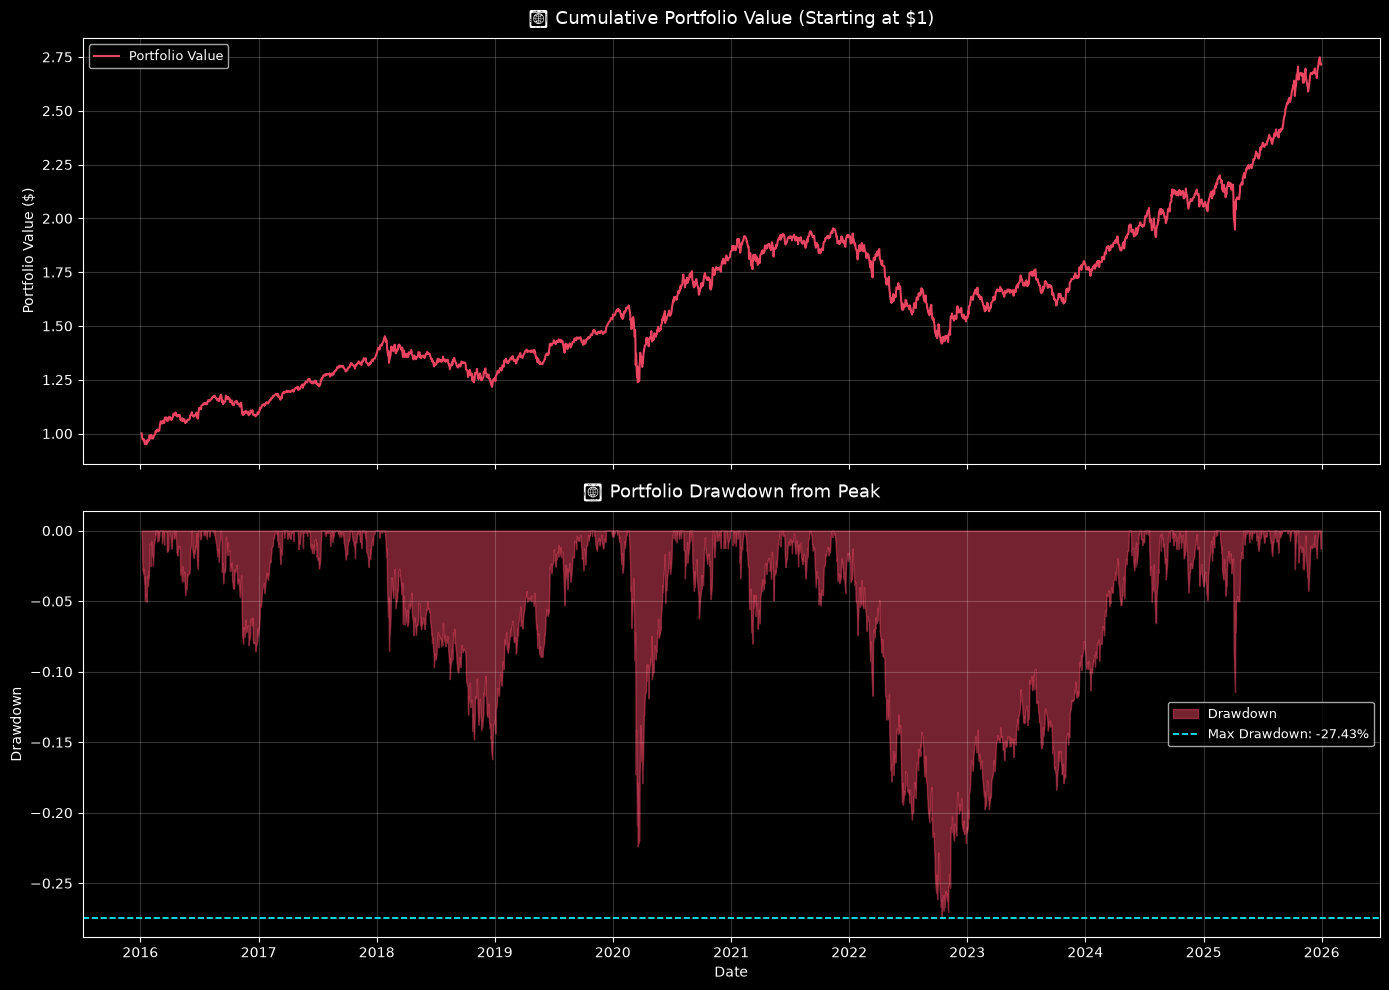

💾 Saved to ../figures/drawdown.png


In [14]:
# Create two charts stacked vertically, sharing the same x-axis (date)
# sharex=True means zooming or panning one chart automatically applies to the other
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top chart: Cumulative Portfolio Value 
# Shows how $1 invested in 2016 grew over the 10-year period
axes[0].plot(cumulative, color="#e94560", linewidth=1.5, label="Portfolio Value")
axes[0].set_title("📈 Cumulative Portfolio Value (Starting at $1)", fontsize=13, pad=10)
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# Bottom chart: Drawdown 
# fill_between fills the area between the drawdown line and zero
# This creates a shaded region — deeper shading = larger drawdown
axes[1].fill_between(drawdown.index, drawdown, 0,
                     color="#e94560", alpha=0.5, label="Drawdown")

# Draw a horizontal dashed line at the maximum drawdown level
# This highlights the single worst point across the entire 10 years
axes[1].axhline(max_drawdown, color="cyan", linestyle="--", linewidth=1.2,
                label=f"Max Drawdown: {max_drawdown*100:.2f}%")

axes[1].set_title("📉 Portfolio Drawdown from Peak", fontsize=13, pad=10)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

# Format x-axis to show just the year number
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../figures/drawdown.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/drawdown.png")

## 📊 Section 8: VaR Comparison Summary

### 📍 Compare All Three Methods

In [15]:
# Build a summary table combining all four risk measures side by side
# Dictionary comprehension {cl: value for cl, v in dict.items()} loops through each
# confidence level and formats the VaR value as a percentage string e.g. "1.279%"
summary = pd.DataFrame({
    "Historical VaR"   : {cl: f"{abs(v)*100:.3f}%" for cl, v in historical_var.items()},
    "Parametric VaR"   : {cl: f"{abs(v)*100:.3f}%" for cl, v in parametric_var.items()},
    "Monte Carlo VaR"  : {cl: f"{abs(v)*100:.3f}%" for cl, v in monte_carlo_var.items()},
    "Expected Shortfall": {cl: f"{abs(v)*100:.3f}%" for cl, v in expected_shortfall.items()}
})

# Replace the raw confidence level numbers (0.90, 0.95, 0.99) with readable labels
summary.index = ["90%", "95%", "99%"]
summary.index.name = "Confidence Level"

print("📊 VaR & ES Comparison Summary")
print("="*65)
print(summary.to_string())

📊 VaR & ES Comparison Summary
                 Historical VaR Parametric VaR Monte Carlo VaR Expected Shortfall
Confidence Level                                                                 
90%                      0.886%         1.029%          1.038%             1.502%
95%                      1.279%         1.333%          1.341%             1.940%
99%                      2.150%         1.903%          1.899%             3.228%


### 📍 Visualise VaR Comparison

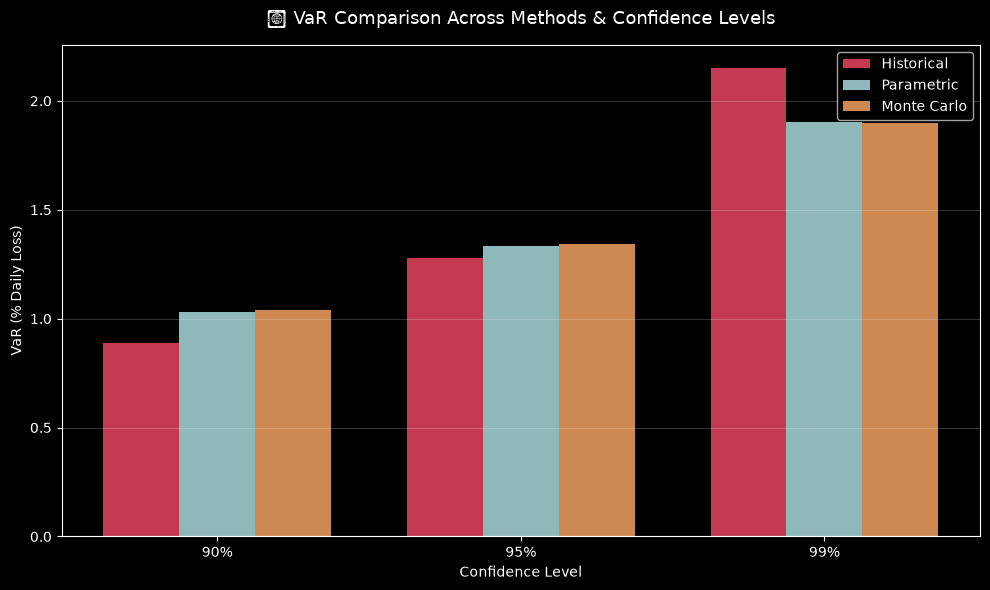

💾 Saved to ../figures/var_comparison.png


In [16]:
# Define the x-axis labels — one group of bars per confidence level
labels = ["90%", "95%", "99%"]

# Create numeric positions for the bar groups on the x-axis [0, 1, 2]
x = np.arange(len(labels))

# Width of each individual bar — 0.25 means 3 bars fit neatly side by side in each group
width = 0.25

# Extract VaR values for each method as plain percentage numbers e.g. [0.886, 1.279, 2.150]
hist_vals  = [abs(historical_var[cl])*100  for cl in CONFIDENCE_LEVELS]
param_vals = [abs(parametric_var[cl])*100  for cl in CONFIDENCE_LEVELS]
mc_vals    = [abs(monte_carlo_var[cl])*100 for cl in CONFIDENCE_LEVELS]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot three sets of bars — each offset slightly so they sit side by side
# x - width positions Historical to the left of centre
# x positions Parametric at centre
# x + width positions Monte Carlo to the right of centre
ax.bar(x - width, hist_vals,  width, label="Historical",  color="#e94560", alpha=0.85)
ax.bar(x,         param_vals, width, label="Parametric",  color="#a8dadc", alpha=0.85)
ax.bar(x + width, mc_vals,    width, label="Monte Carlo", color="#f4a261", alpha=0.85)

ax.set_title("📊 VaR Comparison Across Methods & Confidence Levels", fontsize=13, pad=15)
ax.set_xlabel("Confidence Level")
ax.set_ylabel("VaR (% Daily Loss)")

# Replace numeric x positions [0, 1, 2] with the readable labels ["90%", "95%", "99%"]
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(fontsize=10)
ax.grid(alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("../figures/var_comparison.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/var_comparison.png")

## 💾 Section 9: Save Portfolio Returns

In [17]:
portfolio_returns.to_csv("../data/processed/portfolio_returns.csv")

print("✅ Files saved:")
print("   📄 ../data/processed/portfolio_returns.csv")
print("\n🚀 Ready for NB03 — Streamlit Dashboard")

✅ Files saved:
   📄 ../data/processed/portfolio_returns.csv

🚀 Ready for NB03 — Streamlit Dashboard


## 🪞 Personal Reflection Notes — NB02

**🎯 Key Decisions Made in This Notebook**

The central decision in this notebook was which VaR methods to implement and in what order. I started with historical VaR because it requires no distributional assumptions — it simply reads off the empirical percentile from actual observed returns. This made it the natural baseline. Parametric VaR came second as the textbook approach, and Monte Carlo third as a simulation-based bridge between the two.

The choice of confidence levels (90%, 95%, 99%) was deliberate. 95% is the industry standard for internal risk management. 99% is used under Basel regulatory requirements for bank capital calculations. Including 90% gave a lower bound for comparison. Using all three together shows how risk estimates escalate as you demand more certainty about protecting against tail events.

For Expected Shortfall, I used the historical tail losses rather than the parametric formula. This was intentional — since we already established that returns have fat tails, using the actual observed losses in the tail gives a more honest picture of what happens in the worst scenarios rather than assuming a smooth normal tail.

**📊 What the Results Revealed**

The portfolio's basic statistics were a reasonable starting point. The mean daily return of 0.04% (0.11 annualised) reflects the modest but positive drift of a diversified multi-asset portfolio over the 2016–2025 period. The daily volatility of 0.84% (13.28% annualised) is lower than a pure equity portfolio would produce — which is exactly the point of including TLT and GLD as diversifiers. The worst single day of -7.98% and best of +6.51% confirm the fat tails we identified in NB01.

The historical VaR results tell a clear story. At 95% confidence, the portfolio lost more than 1.28% on 1 in every 20 trading days — roughly once a month. At 99% confidence, losses exceeded 2.15% on 1 in every 99 days — roughly two to three times per year. These are not rare catastrophic events; they are the normal rhythm of risk that a portfolio manager has to budget for every single year.

The most important finding was the comparison between historical and parametric VaR at the 99% confidence level. Historical VaR gave 2.15%, while parametric VaR gave only 1.90% — parametric underestimated tail risk by roughly 13% compared to what actually happened in the data. This confirmed exactly what the fat tails in NB01's return distributions suggested: the normal distribution assigns too low a probability to extreme losses. At 90% and 95% the gap was smaller (0.886% vs 1.029%, and 1.279% vs 1.333% respectively), which makes sense — the fat tail effect becomes more pronounced the deeper into the tail you go. Interestingly, at 90% historical VaR was actually lower than parametric, suggesting the normal distribution slightly overstates risk in the moderate range but significantly understates it in the extreme tail.

Monte Carlo VaR came in almost identical to parametric VaR across all confidence levels (1.038% vs 1.029% at 90%, 1.341% vs 1.333% at 95%, 1.899% vs 1.903% at 99%). This was expected — both methods are grounded in the normal distribution assumption, so they should converge to the same answer. The near-perfect agreement between the two is actually a useful sanity check: it confirms the simulation is working correctly and that 10,000 simulations was sufficient for stable convergence. The Monte Carlo paths chart reinforced this — the fan of 50 simulated 30-day paths spreads out symmetrically around zero, with most paths staying within a ±5% range and a small number of paths diverging to around ±10% by day 30. The symmetry of the fan reflects the normal distribution assumption, and in a more advanced version I could simulate from a fat-tailed distribution to produce a more asymmetric, realistic fan.

Expected Shortfall told the most sobering story. At 95% confidence, ES was 1.94% compared to a VaR of 1.28% — meaning that on the worst 5% of days, the average loss was 1.52 times worse than the VaR threshold alone would suggest. At 99% confidence, ES jumped to 3.23% against a VaR of 2.15% — 1.50 times worse. This gap between VaR and ES is where the real danger lives. A risk manager who only monitors VaR knows the door to the danger zone but has no idea how far the drop is on the other side. ES answers that question, which is why Basel IV regulators replaced VaR with ES as the primary capital requirement metric.

The drawdown analysis grounded all of this in reality. The maximum drawdown of -27.43% occurred on 14 October 2022 — deep into the rate hike cycle that we identified in NB01 as the most aggressive in 40 years. Looking at the drawdown chart, two major troughs are visible: a sharp but brief drawdown during the COVID crash of early 2020, from which the portfolio recovered relatively quickly, and then a deeper, more prolonged trough running through 2022 as rate hikes simultaneously crushed both the equity and bond portions of the portfolio. The 2022 drawdown was worse precisely because the usual hedge broke down — TLT, which normally cushions equity losses, was itself falling sharply. This is the real-world consequence of the weak TLT-equity correlation we observed in NB01's correlation matrix.

What the drawdown chart makes viscerally clear is the difference between a single-day risk measure like VaR and the sustained multi-week losses an investor actually experiences. The daily 99% VaR of 2.15% sounds manageable in isolation. But the drawdown chart shows that losses compounded over months until the portfolio was sitting 27.43% below its prior peak — the kind of sustained pain that tests investor patience and historically triggers panic selling at the worst possible time.

**🔜 What This Sets Up for NB03**

NB03 will bring everything built here into an interactive Streamlit dashboard, allowing the user to adjust portfolio weights and confidence levels dynamically and see how risk estimates change in real time. The key tension to carry forward is the gap between historical and parametric VaR at high confidence levels — this should be surfaced clearly in the dashboard as it is the most practically important finding of this notebook. The maximum drawdown of -27.43% in October 2022 is also worth highlighting prominently in the dashboard, as it connects the abstract risk numbers to a real historical event with a clear economic explanation.